# 1- Importing packages

In [1]:
# import data processing and visualisation libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# import image processing libraries
import cv2
from PIL import Image

# import tensorflow and keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array,load_img
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import os
import random

#import from sklearn
from sklearn.model_selection import train_test_split

2025-10-15 13:56:40.292936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760536600.316887    4465 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760536600.324007    4465 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# import dataset

In [2]:
DATA_DIR = "/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train"

# The content of training data

In [3]:
print(os.listdir(DATA_DIR)[:])

['N', 'R', 'space', 'B', 'I', 'del', 'F', 'H', 'E', 'U', 'M', 'X', 'K', 'Q', 'Y', 'S', 'G', 'A', 'O', 'T', 'V', 'Z', 'C', 'P', 'L', 'W', 'D', 'nothing', 'J']


# Checking for the corrupted data and the extentions of images in dataset  

In [ ]:
def check_corruption(Training_data=DATA_DIR ):
    corrupted_images = []
    extentions = []
    
    sample_images = []
    
    num_samples_per_class = 1  # عدد الصور لكل class
    
    for class_name in os.listdir(Training_data):
        class_path = os.path.join(Training_data, class_name)
        if not os.path.isdir(class_path):
            continue
    
        class_imgs = []
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            root, extention = os.path.splitext(img_path)
            if extention not in extentions:
                extentions.append(extention)
            
            try:
                if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img = Image.open(img_path)
                    img.verify()
                    class_imgs.append(img_path)
            except Exception as es:
                corrupted_images.append(img_path)
                print(f"corrupted image path: {img_path}")
    
        # اختيار أكثر من صورة لكل class
        if class_imgs:
            sample_images.extend(random.sample(class_imgs, min(num_samples_per_class, len(class_imgs))))
    
    print(f"Number of corrupted images: {len(corrupted_images)}")
    print(f"Extensions found: {extentions}")

# Data Extraction

In [5]:
categories={0:'A',
           1:'B',
           2:'C',
           3:'D',
           4:'E',
            5:'F',
            6:'G',
            7:'H',
            8:'I',
            9:'J',
            10:'K',
            11:'L',
            12:'M',
            13:'N',
            14:'O',
            15:'P',
            16:'Q', 
            17:'R',
            18:'S',
            19:'T',
            20:'U',
            21:'V',
            22:'W',
            23:'X',
            24:'Y',
            25:'Z',
            26:'del',
            27:'nothing',
            28:'space'
           
           }

In [6]:
#function to store the image with the full path for easy reaching it during the training  
def add_classNames_prefix(df, col_name, base_path):
    df[col_name] = df.apply(lambda x: os.path.join(base_path, categories[x["Category"]], x["FileName"]), axis=1)
    return df
#list to lis the image name 
file_names_list=[]
#list to list the category of each image 
categories_list=[]

for category in categories:
    filenames=os.listdir(os.path.join(DATA_DIR,categories[category]))
    file_names_list+=filenames
    categories_list+=[category]*len(filenames)

df1=pd.DataFrame({"FileName":file_names_list,"Category":categories_list})
df1=add_classNames_prefix(df1,"FileName",DATA_DIR)

In [7]:
df1

,FileName,Category
0,/kaggle/input/aslamerican-sign-language-aplhab...,0
1,/kaggle/input/aslamerican-sign-language-aplhab...,0
2,/kaggle/input/aslamerican-sign-language-aplhab...,0
3,/kaggle/input/aslamerican-sign-language-aplhab...,0
4,/kaggle/input/aslamerican-sign-language-aplhab...,0
...,...,...
223069,/kaggle/input/aslamerican-sign-language-aplhab...,28
223070,/kaggle/input/aslamerican-sign-language-aplhab...,28
223071,/kaggle/input/aslamerican-sign-language-aplhab...,28
223072,/kaggle/input/aslamerican-sign-language-aplhab...,28


# Data Exploration 

In [8]:
# shuffled dataframe for data expolation
df=pd.DataFrame({"FileName":file_names_list,"Category":categories_list})
df=add_classNames_prefix(df1,"FileName",DATA_DIR)
df = df.sample(frac=1).reset_index(drop=True)


 Showing images from classes in training dataset 

# Data preprocessing

1-showing the original size of images 

In [ ]:
img_shapes = []

for path in df["FileName"]:  
    img = cv2.imread(path)    
    if img is not None:       
        img_shapes.append(img.shape)  

print(set(img_shapes)) 


2- function to resize images 

In [9]:
train_dfs = []
test_dfs = []
val_dfs = []

for category in df1["Category"].unique():
    df_cat = df1[df1["Category"] == category]

    # train/test split
    train_cat, test_cat = train_test_split(df_cat, test_size=0.2, random_state=42)
    
    # train/validation split
    train_cat, val_cat = train_test_split(train_cat, test_size=0.1, random_state=42)

    train_dfs.append(train_cat)
    test_dfs.append(test_cat)
    val_dfs.append(val_cat)

# ندمجهم
train_df = pd.concat(train_dfs).reset_index(drop=True)
test_df = pd.concat(test_dfs).reset_index(drop=True)
val_df = pd.concat(val_dfs).reset_index(drop=True)

print("Train:", len(train_df), "Test:", len(test_df), "Val:", len(val_df))



Train: 160589 Test: 44627 Val: 17858


In [10]:
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [12]:
def load_data_from_df(df, img_size=64, grayscale=True):
    data = []
    labels = []

    classes = sorted(df["Category"].unique())
    class_to_index = {cls: idx for idx, cls in enumerate(classes)}

    for _, row in df.iterrows():
        try:
            if grayscale:
                img = cv2.imread(row["FileName"], cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0
                img = np.expand_dims(img, axis=-1)
            else:
                img = cv2.imread(row["FileName"])
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0

            data.append(img)
            labels.append(class_to_index[row["Category"]])
        except:
            pass
    
    return np.array(data, dtype="float32"), np.array(labels), classes


In [13]:
# processing training data
X_train,y_train,train_classes=load_data_from_df(train_df)


In [ ]:
y_train

In [14]:
y_train.shape

(160589,)

In [ ]:
train_classes


In [15]:
#processing test data
X_tests,y_tests,test_classess=load_data_from_df(test_df)

In [17]:
#processing vaidation data
X_validat,y_validat,validat_classes=load_data_from_df(val_df)

In [18]:
y_validat.shape

(17858,)

# showing an image after applying the preproccing   

3- convert labels into one hot encodded classes

In [19]:
y_train = to_categorical(y_train, num_classes=len(train_classes))

In [20]:
y_train.shape

(160589, 29)

In [ ]:
y_train

In [21]:
y_tests = to_categorical(y_tests, num_classes=len(test_classess))

In [22]:
y_tests.shape

(44627, 29)

In [26]:
y_validat = to_categorical(y_validat, num_classes=len(validat_classes))

In [27]:
y_validat.shape

(17858, 29)

In [ ]:
print(y_test.shape)


# Display some images after preprocessing 

In [ ]:
def show_samples(X, y, classes, n=5, title="Samples"):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(X[i].squeeze(), cmap="gray")  # squeeze() لو الصور grayscale
        # Decode the one-hot encoded label back to an integer index
        class_index = np.argmax(y[i])
        plt.title(classes[class_index])
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.show()

# عرض عينات من Train
show_samples(X_train, y_train, train_classes, n=5, title="Train Samples")

# Building model

In [28]:
from keras.models import Sequential
from keras.layers import Conv2D ,MaxPooling2D, Activation, Dense,BatchNormalization,Dropout,Flatten
from keras.callbacks import EarlyStopping , ReduceLROnPlateau,ModelCheckpoint
import tensorflow as tf
import keras
from tensorflow.keras import regularizers

In [29]:
#model
CNN_model= Sequential()

#Block1
CNN_model.add(Conv2D(16,(3,3),padding="same",input_shape=(64,64,1)))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation('relu'))
CNN_model.add(Conv2D(16,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation("relu"))
CNN_model.add(MaxPooling2D(pool_size=(2,2)))
CNN_model.add(Dropout(0.2))

#block2
CNN_model.add(Conv2D(32,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation('relu'))
CNN_model.add(Conv2D(32,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation("relu"))
CNN_model.add(MaxPooling2D(pool_size=(2,2)))
CNN_model.add(Dropout(0.25))

#block3
CNN_model.add(Conv2D(64,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation('relu'))
CNN_model.add(Conv2D(64,(3,3),padding="same"))
CNN_model.add(BatchNormalization())
CNN_model.add(Activation("relu"))
CNN_model.add(MaxPooling2D(pool_size=(2,2)))
CNN_model.add(Dropout(0.3))

#flatten 
CNN_model.add(Flatten())

#fully coneected layer 
CNN_model.add(Dense(512,activation="relu",kernel_regularizer=regularizers.l2(0.0001)))
CNN_model.add(Dropout(0.3))


#output layer 
CNN_model.add(Dense(29,activation="softmax"))

CNN_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1760537780.591986    4465 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             

 Total params: 2,185,229 (8.34 MB)

 Trainable params: 2,184,781 (8.33 MB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
#optimzer
CNN_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [31]:
#callbacks
callback=[
tf.keras.callbacks.ModelCheckpoint ("best.h5",save_best_only=True,monitor='val_accuracy'),
tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy',patience=3,factor=0.5),
tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=6,restore_best_weights=True)]

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10, # rotation by + or - 10 degree
    width_shift_range=0.1,#shifting width of image by 10%
    height_shift_range=0.1,#shifting height by 10%
    zoom_range=0.1,#zoom in or out by 10
    horizontal_flip=False,# preventing pliping for the misleading 
    fill_mode="nearest"
)
datagen.fit(X_train)


In [33]:
#fitting model
histroy=CNN_model.fit(datagen.flow(X_train,y_train),batch_size=64,epochs=40,validation_data=(X_validat,y_validat),callbacks=callback)

Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1760537819.167505    4516 service.cc:148] XLA service 0x7b102c0200d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760537819.167569    4516 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760537819.815602    4516 cuda_dnn.cc:529] Loaded cuDNN version 90300


  10/5019 ━━━━━━━━━━━━━━━━━━━━ 1:36 19ms/step - accuracy: 0.0358 - loss: 4.9393     

I0000 00:00:1760537825.037714    4516 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5019/5019 ━━━━━━━━━━━━━━━━━━━━ 108s 19ms/step - accuracy: 0.1433 - loss: 3.1062 - val_accuracy: 0.6536 - val_loss: 1.2304 - learning_rate: 1.0000e-04
Epoch 2/40
5019/5019 ━━━━━━━━━━━━━━━━━━━━ 88s 17ms/step - accuracy: 0.5765 - loss: 1.4419 - val_accuracy: 0.8576 - val_loss: 0.5718 - learning_rate: 1.0000e-04
Epoch 3/40
5019/5019 ━━━━━━━━━━━━━━━━━━━━ 90s 18ms/step - accuracy: 0.7348 - loss: 0.8979 - val_accuracy: 0.9068 - val_loss: 0.3839 - learning_rate: 1.0000e-04
Epoch 4/40
5019/5019 ━━━━━━━━━━━━━━━━━━━━ 88s 18ms/step - accuracy: 0.8038 - loss: 0.6754 - val_accuracy: 0.9270 - val_loss: 0.3039 - learning_rate: 1.0000e-04
Epoch 5/40
5019/5019 ━━━━━━━━━━━━━━━━━━━━ 88s 18ms/step - accuracy: 0.8471 - loss: 0.5480 - val_accuracy: 0.9618 - val_loss: 0.2157 - learning_rate: 1.0000e-04
Epoch 6/40
5019/5019 ━━━━━━━━━━━━━━━━━━━━ 87s 17ms/step - accuracy: 0.8736 - loss: 0.4655 - val_accuracy: 0.9654 - val_loss: 0.1998 - learning_rate: 1.0000e-04
Epoch 7/40
5019/5019 ━━━━━━━━━━━━━━━━━━━━ 84s 17ms

In [41]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# تحميل الموديل
model = load_model("best.h5")

# تحميل الصورة الجديدة
img = cv2.imread("/kaggle/input/letter-a/AA.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (64, 64))
img = img / 255.0
img = np.expand_dims(img, axis=-1)
img = np.expand_dims(img, axis=0)

# التنبؤ
pred = model.predict(img)
predicted_class = np.argmax(pred)

# لو عندك قائمة الحروف بالترتيب
labels = ['A', 'B', 'C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R',
    'S','T','U','V','W','X','Y','Z','del','nothing','space']  # حسب ترتيب الـy_train
print("Predicted class:", labels[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
Predicted class: A


In [34]:
metrics = pd.DataFrame(histroy.history)
print("The model metrics are")
metrics

The model metrics are


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.273281,2.557268,0.653601,1.230426,0.000100
1,0.624663,1.268900,0.857599,0.571800,0.000100
2,0.755251,0.831373,0.906764,0.383858,0.000100
3,0.816538,0.638534,0.927036,0.303862,0.000100
4,0.853259,0.528060,0.961810,0.215698,0.000100
5,0.877370,0.455492,0.965394,0.199848,0.000100
6,0.893374,0.407424,0.967242,0.189268,0.000100
7,0.906295,0.370522,0.975473,0.166846,0.000100
8,0.915966,0.342126,0.972057,0.177543,0.000100
9,0.924216,0.317980,0.980065,0.149939,0.000100


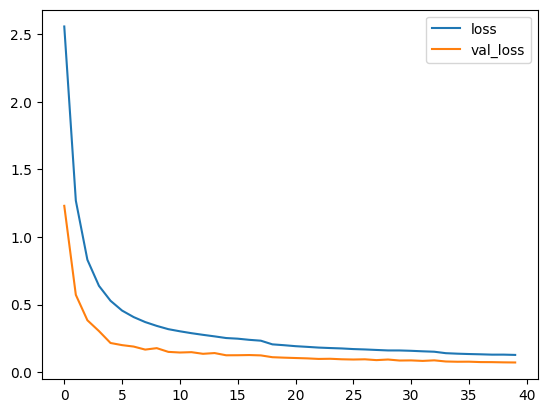

In [35]:
metrics[['loss','val_loss']].plot()
plt.show()

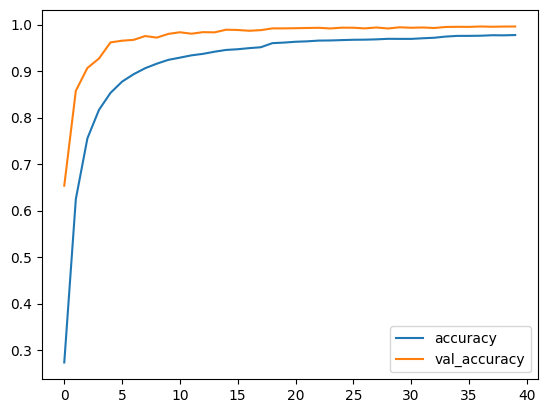

In [36]:
metrics[['accuracy','val_accuracy']].plot()
plt.show()

In [37]:
CNN_model.evaluate(X_tests,y_tests,verbose=0)

[0.07371174544095993, 0.9957424998283386]